In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

df = pd.read_csv(
    '../cleaned-data/master_orders.csv',
    parse_dates=['order_purchase_timestamp']
)

print(f"Loaded: {df.shape}")
df.head()

Loaded: (119143, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,...,customer_state,customer_city,product_id,seller_id,price,freight_value,product_category_name_english,payment_type,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,8.0,0,...,SP,sao paulo,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,credit_card,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,8.0,0,...,SP,sao paulo,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,voucher,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,8.0,0,...,SP,sao paulo,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,voucher,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018,13.0,0,...,BA,barreiras,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumery,boleto,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018,9.0,0,...,GO,vianopolis,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,auto,credit_card,179.12,5.0


In [2]:
# Filter delivered orders only

delivered = df[
    df['order_status'] == 'delivered'
].copy()

print(
    f"Delivered orders: "
    f"{delivered.shape[0]:,}"
)

delivered.head()

Delivered orders: 115,723


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,...,customer_state,customer_city,product_id,seller_id,price,freight_value,product_category_name_english,payment_type,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,8.0,0,...,SP,sao paulo,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,credit_card,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,8.0,0,...,SP,sao paulo,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,voucher,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,8.0,0,...,SP,sao paulo,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,voucher,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018,13.0,0,...,BA,barreiras,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumery,boleto,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018,9.0,0,...,GO,vianopolis,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,auto,credit_card,179.12,5.0


In [5]:
# Convert timestamp column to datetime
delivered['order_purchase_timestamp'] = pd.to_datetime(
    delivered['order_purchase_timestamp'],
    dayfirst=True
)

# Set reference date as 1 day after last purchase
reference_date = (
    delivered['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

print(f"Reference date: {reference_date}")

# Compute RFM
rfm = delivered.groupby('customer_id').agg(

    recency=(
        'order_purchase_timestamp',
        lambda x: (reference_date - x.max()).days
    ),

    frequency=(
        'order_id',
        'nunique'
    ),

    monetary=(
        'payment_value',
        'sum'
    )

).reset_index()

print(rfm.describe())
rfm.head()

Reference date: 2018-08-30 15:00:00
            recency  frequency      monetary
count  96478.000000    96478.0   96478.00000
mean     240.121862        1.0     206.07750
std      152.837005        0.0     624.75039
min        1.000000        1.0       0.00000
25%      116.000000        1.0      62.83000
50%      221.000000        1.0     110.02000
75%      350.000000        1.0     196.09500
max      714.000000        1.0  109312.64000


,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74
1,000161a058600d5901f007fab4c27140,410,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35
4,000379cdec625522490c315e70c7a9fb,150,1,107.01


In [6]:
# Recency: lower days = better = higher score
rfm['R_score'] = pd.qcut(
    rfm['recency'],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency: higher = better
rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary: higher = better
rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Combined RFM score
rfm['RFM_score'] = (
    rfm['R_score'].astype(str)
    + rfm['F_score'].astype(str)
    + rfm['M_score'].astype(str)
)

print(rfm.head(10))

                        customer_id  recency  frequency  monetary  R_score  \
0  00012a2ce6f8dcda20d059ce98491703      288          1    114.74        2   
1  000161a058600d5901f007fab4c27140      410          1     67.41        1   
2  0001fd6190edaaf884bcaf3d49edf079      548          1    195.42        1   
3  0002414f95344307404f0ace7a26f1d5      379          1    179.35        2   
4  000379cdec625522490c315e70c7a9fb      150          1    107.01        4   
5  0004164d20a9e969af783496f3408652      505          1     71.80        1   
6  000419c5494106c306a97b5635748086      180          1     49.40        4   
7  00046a560d407e99b969756e0b10f282      255          1    166.59        3   
8  00050bf6e01e69d5c0fd612f1bcfb69c      346          1     85.23        2   
9  000598caf2ef4117407665ac33275130       19          1   1255.71        5   

   F_score  M_score RFM_score  
0        1        3       213  
1        1        2       112  
2        1        4       114  
3        1   

In [7]:
# Assign customer segments

def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 3:
        return 'Loyal'

    elif r >= 4 and f <= 2:
        return 'Potential Loyalist'

    elif r <= 2 and f >= 3:
        return 'At-Risk'

    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'

    else:
        return 'Needs Attention'


rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['Segment'].value_counts())

Segment
Loyal                 28350
At-Risk               23246
Needs Attention       16678
Potential Loyalist    15606
Lost                   6307
Champions              6291
Name: count, dtype: int64


In [8]:
# Segment summary

segment_summary = rfm.groupby('Segment').agg(
    customer_count=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2)

segment_summary['pct_customers'] = (
    segment_summary['customer_count']
    / segment_summary['customer_count'].sum()
    * 100
).round(1)

print(segment_summary)

                    customer_count  avg_recency  avg_frequency  avg_monetary  \
Segment                                                                        
At-Risk                      23246       397.31            1.0        205.40   
Champions                     6291        93.35            1.0        405.46   
Lost                          6307       397.25            1.0         55.42   
Loyal                        28350       145.04            1.0        162.03   
Needs Attention              16678       316.85            1.0        260.82   
Potential Loyalist           15606        92.37            1.0        209.13   

                    total_revenue  pct_customers  
Segment                                           
At-Risk                4774673.64           24.1  
Champions              2550732.33            6.5  
Lost                    349526.45            6.5  
Loyal                  4593412.89           29.4  
Needs Attention        4349885.41           17.3  
Po

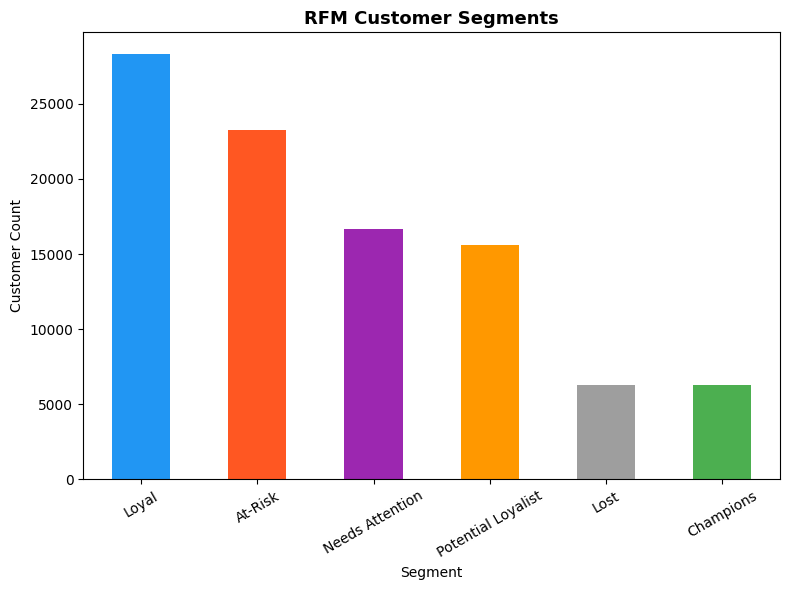

In [9]:
# RFM Segment Chart

colors = {
    'Champions': '#4CAF50',
    'Loyal': '#2196F3',
    'Potential Loyalist': '#FF9800',
    'At-Risk': '#FF5722',
    'Lost': '#9E9E9E',
    'Needs Attention': '#9C27B0'
}

seg_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 6))

seg_counts.plot(
    kind='bar',
    color=[colors.get(s, '#607D8B') for s in seg_counts.index]
)

plt.title('RFM Customer Segments', fontsize=13, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Customer Count')
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    '../process-diagrams/rfm_segments.png',
    dpi=150
)

plt.show()

In [10]:
# Save RFM segmentation file for Power BI

rfm.to_csv(
    '../cleaned-data/rfm_segments.csv',
    index=False
)

print(
    f"RFM file saved: "
    f"{rfm.shape[0]:,} customers segmented"
)

RFM file saved: 96,478 customers segmented


## RFM Key Findings

- Champions: 6,291 customers (6.5%) — highest value, most recent customers with avg spend of R$405

- At-Risk: 23,246 customers (24.1%) — previously active customers now becoming inactive, representing R$4.77M in revenue

- Lost: 6,307 customers (6.5%) — low-spending inactive customers with avg spend of R$55

- Loyal: 28,350 customers (29.4%) — largest customer segment contributing R$4.59M in revenue

- Business implication:
At-Risk customers represent approximately R$4.77M in recoverable revenue. Even a 20% reactivation campaign could recover ~R$954K in revenue.